# Project Workflow
### In this project I will follow the following Data Science and machine learning Workflow
***1- Prepare Data***    
    - Import  
    - Explore  
    - Split  

***2- Build Model***    
    - Baseline  
    - Iterate  
    - Evaluation  

***3- Communicating Results***   

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.stats import stats
from IPython.display import display, HTML

In [61]:
# import data
df = pd.read_csv("../data/raw/train.csv")

In [62]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [63]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [64]:
# summary statistics about the numerical features
num_features = df.select_dtypes(include=[np.number])
num_features.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [65]:
# summary about the categorical features
cat_features = df.select_dtypes(include=[object])
cat_features.describe()

C:\Users\m\AppData\Local\Temp\ipykernel_14216\2607119162.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = df.select_dtypes(include=[object])


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


As shown above the pd.describe() method works diffrently with the numerical and categorical data, for each type there is it's aggregations

In [66]:
df.shape

(1460, 81)

In [67]:
# Nulls
nulls = df.isna().sum()
nulls

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [68]:
# Null percentage of each feature to the total nulls
null_perc = (nulls/df.shape[0]) * 100
null_perc

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64

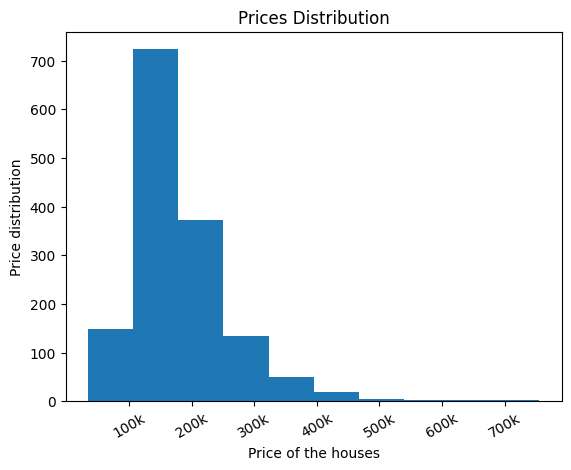

In [69]:
# Histogram of the prices
df["SalePrice"].plot(kind="hist")
plt.xticks(
    ticks=[100000,200000,300000,400000,500000,600000,700000],
    labels=["100k","200k", "300k", "400k", "500k", "600k", "700k"], rotation=30);
plt.xlabel("Price of the houses")
plt.ylabel("Price distribution")
plt.title("Prices Distribution")
plt.savefig("../reports/figures/Prices_hist.png", dpi=150)


In [70]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


### from the values of the mean, median it's clearly that this distribution is right scewed as it shown in the histogram above

# EDA
### During the EDA we need to answer several question related to the price and tha relationship between the price and the other feature, such as:
### 1- Price and dwelling types
### 2- Price and zones
### 3- Price and street structure
### 4- Price and property shape
### 5- Price and property age
### 6- Price and living areas
### 7- Price changing over the years

# Price and dwelling types

In [71]:

dwelling_types = df["BldgType"].value_counts()
dwelling_prices = df.groupby("BldgType")["SalePrice"].mean().sort_values(ascending=False)
dwelling_prices

BldgType
1Fam      185763.807377
TwnhsE    181959.342105
Twnhs     135911.627907
Duplex    133541.076923
2fmCon    128432.258065
Name: SalePrice, dtype: float64

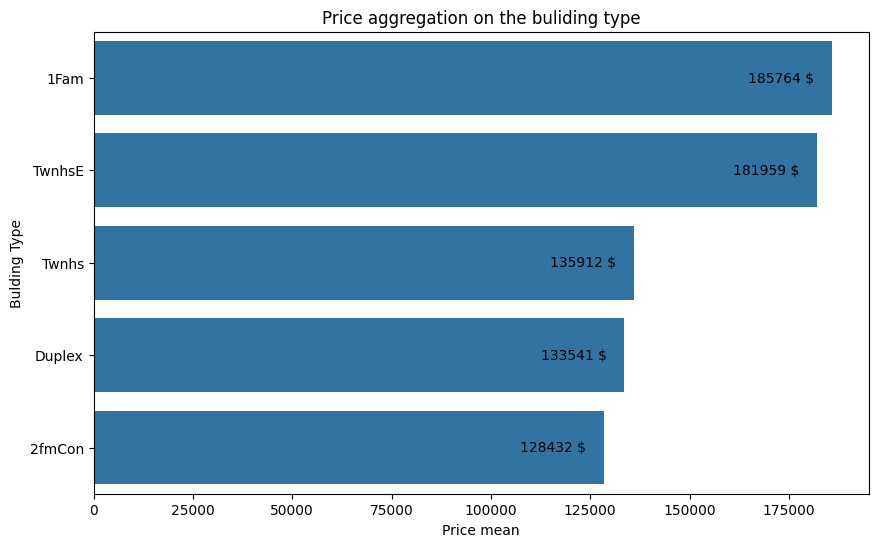

In [72]:
fig,ax = plt.subplots(figsize=(10,6))
sns.barplot(dwelling_prices,ax=ax,orient="h");
plt.xlabel("Price mean")
plt.ylabel("Bulding Type")
ax.bar_label(ax.containers[0], label_type="edge", padding=-60, fmt="%.0f $")
plt.title("Price aggregation on the buliding type");
plt.savefig("../reports/figures/dwelling_prices.png", dpi=150)

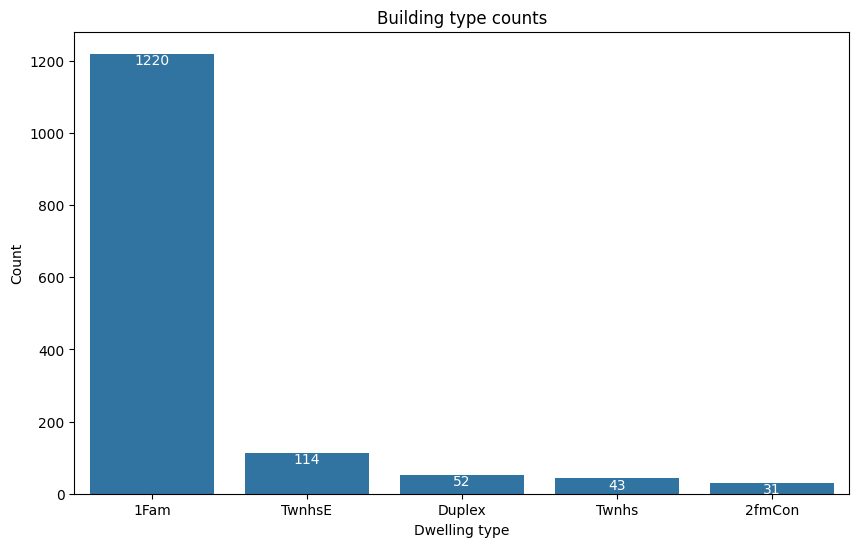

<Figure size 640x480 with 0 Axes>

In [73]:
fig, ax = plt.subplots(figsize = (10,6))
sns.barplot(dwelling_types, ax=ax)
ax.set_xlabel("Dwelling type")
ax.set_ylabel("Count")
ax.bar_label(ax.containers[0], padding=-10, fmt="%.0f", label_type="edge", color="white")
plt.title("Building type counts")
plt.show()
plt.savefig("../reports/figures/dwelling_types.png", dpi=150)

### The most common dwelling type is single-family homes, while the least common is two-family conversion homes, Also the single-family homes seems to be the most expensive ones

# Price and zoning

### The MSZoning column represents the general zoning classification of each property, such as:

RL → Residential Low Density.   
RM → Residential Medium Density.  
RH → Residential High Density.  
FV → Floating Village Residential.  
C → Commercial.  
A → Agriculture.  
I → Industrial.  
RP → Residential Low Density Park.  

In [74]:
zoning_types = df["MSZoning"].value_counts()
zoning_types

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

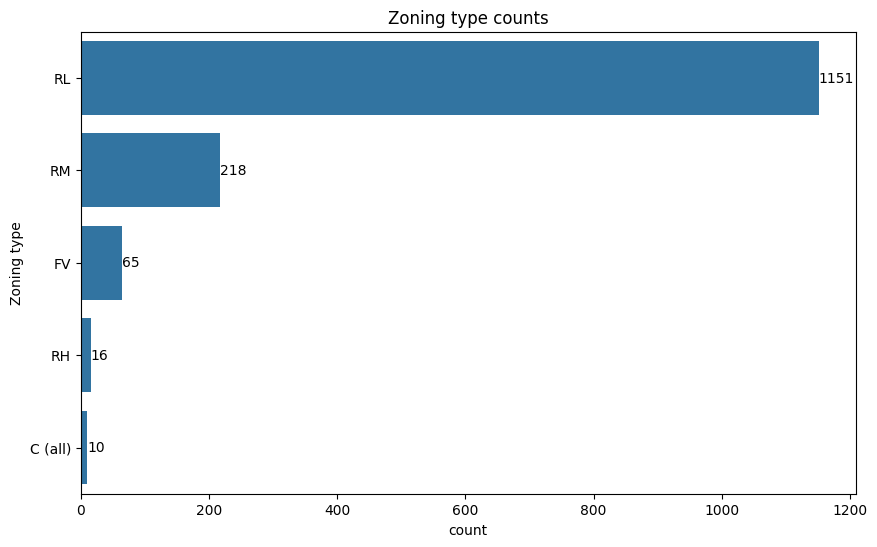

<Figure size 640x480 with 0 Axes>

In [75]:
fig, ax = plt.subplots(figsize = (10,6))
sns.barplot(zoning_types, ax=ax, orient="h")
ax.set_xlabel("count")
ax.set_ylabel("Zoning type")
ax.bar_label(ax.containers[0],  fmt="%.0f")
plt.title("Zoning type counts")
plt.show()
plt.savefig("../reports/figures/zoning_types.png", dpi=150)


In [76]:
# price and zoningn impact of zonings on the price
zon_prices = df.groupby("MSZoning")["SalePrice"].mean().sort_values(ascending=False)
zon_prices

MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

### Of course the Floating Village Residentials is the most expensive ones however, the Number Floating Village Residentials are not the most common

C:\Users\m\AppData\Local\Temp\ipykernel_14216\2035043282.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show();


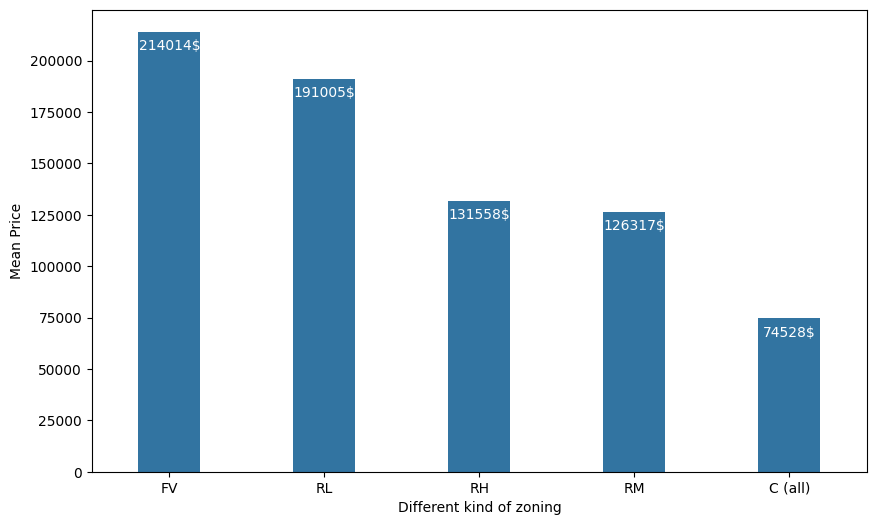

In [77]:
fig, ax = plt.subplots(figsize = (10,6))
sns.barplot(zon_prices, ax=ax, width=0.4)
ax.set_xlabel("Different kind of zoning")
ax.set_ylabel("Mean Price")
ax.bar_label(ax.containers[0], label_type="edge", padding=-15, color="white", fmt="%.0f$")
fig.show();
plt.savefig("../reports/figures/zon_prices.png", dpi=150)

# Price vs streets and alley

In [78]:
df["Street"].value_counts()

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

In [79]:
df["Alley"].value_counts()

Alley
Grvl    50
Pave    41
Name: count, dtype: int64

In [80]:
street_prices = df.groupby("Street")["SalePrice"].mean()
alley_prices = df.groupby("Alley")["SalePrice"].mean()

In [81]:
street_prices

Street
Grvl    130190.500000
Pave    181130.538514
Name: SalePrice, dtype: float64

In [82]:
alley_prices

Alley
Grvl    122219.080000
Pave    168000.585366
Name: SalePrice, dtype: float64

C:\Users\m\AppData\Local\Temp\ipykernel_14216\312890372.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


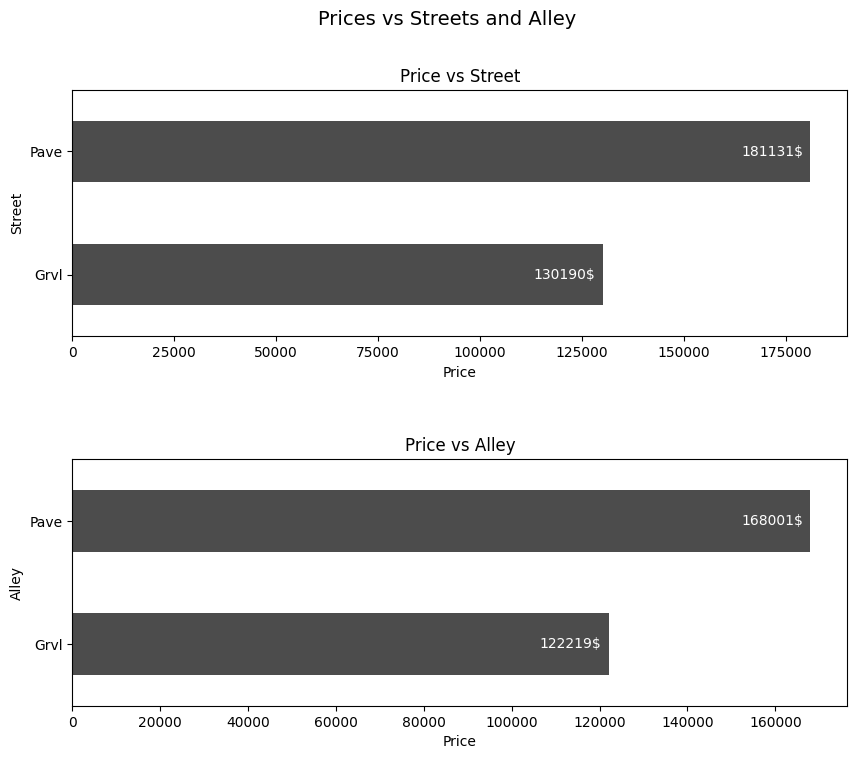

In [83]:
fig,ax = plt.subplots(2, figsize=(10,8))
street_prices.plot(ax=ax[0], kind="barh", color="black", alpha=0.7)
ax[0].set_xlabel("Price")
ax[0].set_title("Price vs Street")
ax[0].bar_label(ax[0].containers[0], label_type="edge", padding=-50, color="white", fmt="%.0f$")

alley_prices.plot(ax=ax[1], kind="barh", color="black", alpha=0.7)
ax[1].set_title("Price vs Alley")
ax[1].set_xlabel("Price")
ax[1].bar_label(ax[1].containers[0], label_type="edge", padding=-50, color="white", fmt="%.0f$")

fig.suptitle("Prices vs Streets and Alley", fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.show()
plt.savefig("../reports/figures/street_alleys_prices.png", dpi=150)

 From the graph above, Houses with paved street and alley access appear to have greater market value, likely due to better infrastructure and accessibility compared to properties connected to gravel roads.

# Price and Property shape
### LotShape and LandContour describe different physical characteristics of the property in our Dataset.

### 1. LotShape
Describes the shape of the land parcel (geometry of the lot).

### 2. LandContour

Describes the topography / flatness of the property.

In [84]:
df["LotShape"].value_counts()

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

In [85]:
df["LandContour"].value_counts()

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

In [86]:
shape_prices = df.groupby(["LotShape"])["SalePrice"].mean().sort_values()
shape_prices

LotShape
Reg    164754.818378
IR1    206101.665289
IR3    216036.500000
IR2    239833.365854
Name: SalePrice, dtype: float64

In [87]:
flatness_prices = df.groupby(["LandContour"])["SalePrice"].mean().sort_values()
flatness_prices

LandContour
Bnk    143104.079365
Lvl    180183.746758
Low    203661.111111
HLS    231533.940000
Name: SalePrice, dtype: float64

C:\Users\m\AppData\Local\Temp\ipykernel_14216\2324731268.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


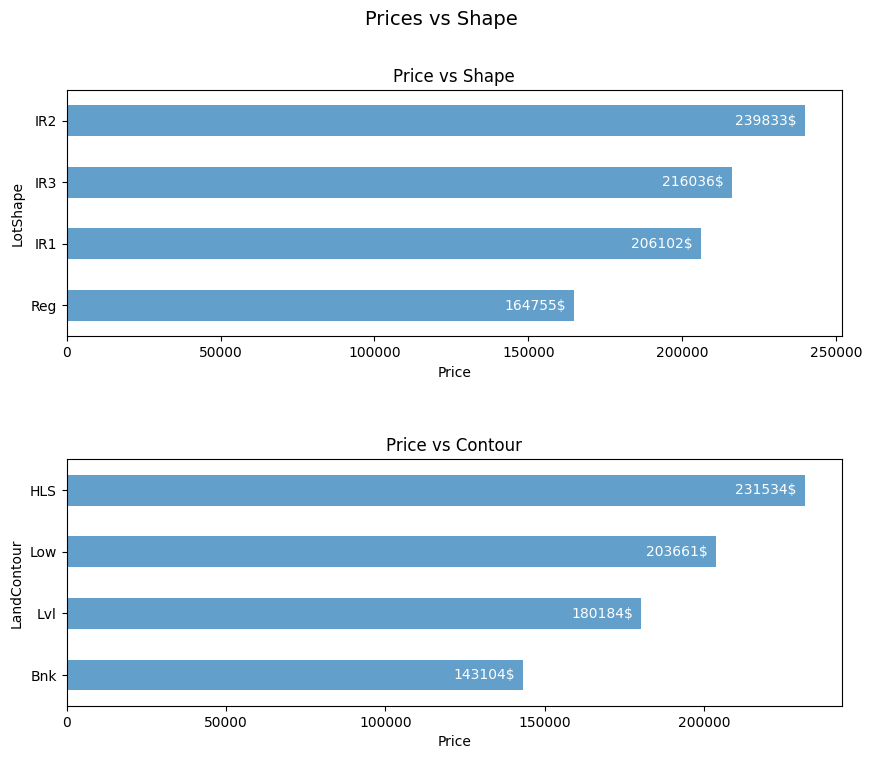

In [88]:
fig,ax = plt.subplots(2, figsize=(10,8))
shape_prices.plot(ax=ax[0], kind="barh",alpha=0.7)
ax[0].set_xlabel("Price")
ax[0].set_title("Price vs Shape")
ax[0].bar_label(ax[0].containers[0], label_type="edge", padding=-50, color="white", fmt="%.0f$")

flatness_prices.plot(ax=ax[1], kind="barh",alpha=0.7)
ax[1].set_title("Price vs Contour")
ax[1].set_xlabel("Price")
ax[1].bar_label(ax[1].containers[0], label_type="edge", padding=-50, color="white", fmt="%.0f$")

fig.suptitle("Prices vs Shape", fontsize=14)
fig.subplots_adjust(hspace=0.5)
fig.show()
plt.savefig("../reports/figures/property_shape.png", dpi=150)

### Property Shape and Land Contour Insights

Regularly shaped land is generally easier to build on and organize efficiently.  
However, the analysis shows that houses with irregular lot shapes tend to have higher sale prices.

Similarly, properties located on non-flat land contours — especially hillside (`HLS`) areas — appear to be more expensive.  
This may be explained by:
- scenic and panoramic views,
- premium neighborhood locations,
- and increased property uniqueness.

Overall, while regular and level land may offer better construction practicality, irregular and hillside properties can provide greater aesthetic and market value.

# Price and property age

In [89]:
df["YrSold"].head()

0    2008
1    2007
2    2008
3    2006
4    2008
Name: YrSold, dtype: int64

In [90]:
df["YearBuilt"].head()

0    2003
1    1976
2    2001
3    1915
4    2000
Name: YearBuilt, dtype: int64

In [91]:
df["PropAge"] = df.apply(lambda x:x["YrSold"] - x["YearBuilt"], axis=1)
df["PropAge"]

0        5
1       31
2        7
3       91
4        8
        ..
1455     8
1456    32
1457    69
1458    60
1459    43
Name: PropAge, Length: 1460, dtype: int64

In [92]:
# property age corelation to the sale price
age_pr_corr = df["PropAge"].corr(df["SalePrice"])
age_pr_corr

np.float64(-0.5233504175468159)

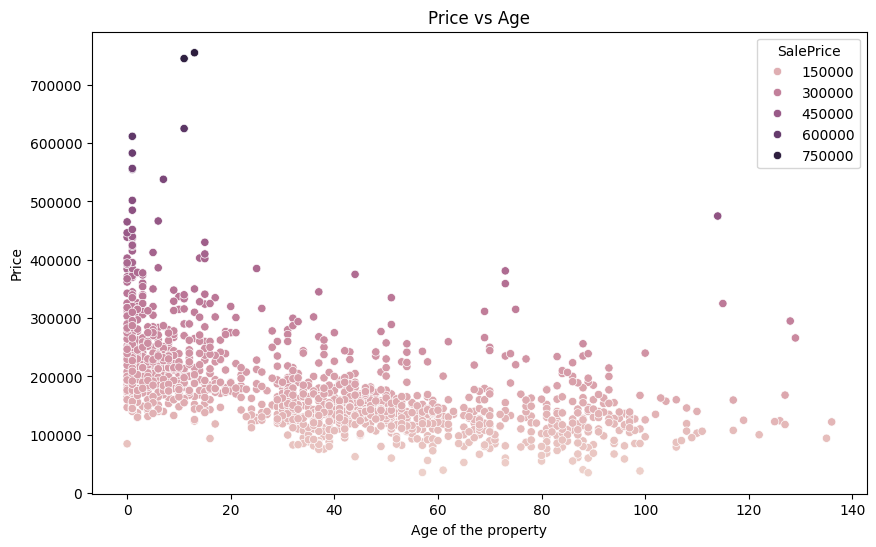

<Figure size 640x480 with 0 Axes>

In [93]:
fig,ax =plt.subplots(figsize=(10,6))
sns.scatterplot(data = df, x="PropAge", y="SalePrice", hue= "SalePrice")
ax.set_title("Price vs Age")
ax.set_ylabel("Price")
ax.set_xlabel("Age of the property")
plt.show();
plt.savefig("../reports/figures/price_vs_age.png", dpi=150)

### Property Age and Sale Price

The analysis shows that older houses tend to be cheaper than newer houses.  
As the property age increases, the sale price generally decreases.

This negative relationship may be explained by:
- higher maintenance costs,
- outdated designs and materials,
- reduced energy efficiency,
- and the need for renovations or remodeling.

In contrast, newer homes are usually more expensive because they offer:
- modern construction quality,
- updated facilities,
- better insulation and energy efficiency,
- and lower maintenance requirements.

# Price and Living area

In [94]:
# correlation between living are (above grade) and the Price
liv_area_price_corr = df["GrLivArea"].corr(df["SalePrice"])
liv_area_price_corr

np.float64(0.7086244776126521)

In [95]:
fig = px.scatter(data_frame=df, x="GrLivArea", y="SalePrice", 
                 color="GrLivArea",
                 title="Price vs Living area")
fig.update_layout(xaxis_title="Living area [Above Grade]", yaxis_title = "Price")
fig.show()
plt.savefig("../reports/figures/area_vs_price.png", dpi=150)

<Figure size 640x480 with 0 Axes>

### Living Area and Sale Price Relationship

As shown in the analysis, the **above-ground living area (GrLivArea)** is one of the most positively correlated features with house prices.

This means that as the living area increases, the sale price of the house also tends to increase.

This strong positive relationship is expected because larger homes generally provide:
- more usable space,
- greater comfort,
- and higher market value.

Therefore, GrLivArea is considered one of the most important predictors of house prices in the dataset.

# Price over years

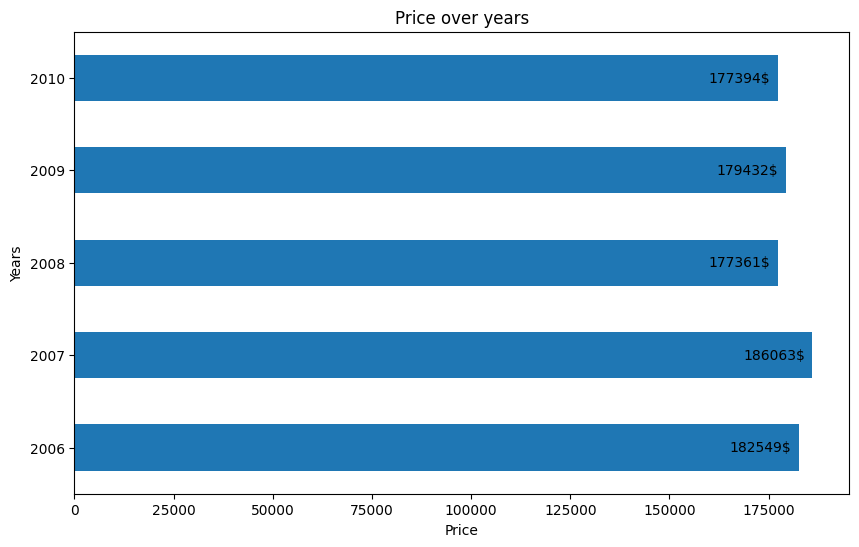

<Figure size 640x480 with 0 Axes>

In [96]:
fig,ax = plt.subplots(figsize=(10,6))
df.groupby("YrSold")["SalePrice"].mean().plot(kind="barh")
plt.xlabel("Price")
plt.ylabel("Years")
plt.title("Price over years")
plt.bar_label(ax.containers[0], padding=-50, fmt="%.0f$")
plt.show();
plt.savefig("../reports/figures/price_over_years.png", dpi=150)

In [99]:
fig = px.box(
    data_frame =df,
    x="YrSold",
    y="SalePrice",
    title="Price over years"
)
fig.update_layout(xaxis_title = "Years", yaxis_title = "Price over years")
fig.show()


# Data Pipeline

In [100]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [101]:
# Transformers for numerical and categorical features
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
     ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant',fill_value="missing")),
    ('onehot',OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    
])

In [102]:
# Update Numerical and categorical features
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# remove out target 'SalePrice' from the numerical columns
numerical_columns = numerical_columns.drop('SalePrice')

# Preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer,numerical_columns ),
    ('cat', cat_transformer, categorical_columns)
], remainder='passthrough')

# preprocessor pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

# Apply the Pipeline to the dataset, Horizontal Data splitting
X = df.drop("SalePrice", axis=1)
y= np.log(df["SalePrice"]) # Normalize the Target(dependent) vaariable
X_preprocessed = pipeline.fit_transform(X)

C:\Users\m\AppData\Local\Temp\ipykernel_14216\1732952584.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


# Split the data
Vertical split


In [103]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X_preprocessed,y, test_size=0.2, random_state=42)

# Models

In [104]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
import warnings

warnings.filterwarnings("ignore")

In [105]:
# define the models
models ={
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(random_state=42),
    "XGBoost" : XGBRegressor(random_state=42)   
}

param_grids ={
    "LinearRegression": {},
    "RandomForest": {
        "n_estimators":[100,200,500],
        "max_depth":[None, 10,30],
        "min_samples_split":[2,5,10]
    },
    "XGBoost": {
        "n_estimators":[100,200,500],
        "learning_rate":[0.01, 0.1, 0.3],
        "max_depth":[3, 6, 10]
        
    }
}

# 3-folds cross validation
cv = KFold(n_splits=3, shuffle=True, random_state=42)

# Traing the model and hyperparameter tuning
grids={}
for model_name, model in models.items():
    grids[model_name] = GridSearchCV(estimator=model, 
                                     param_grid=param_grids[model_name], 
                                     cv=cv, scoring="neg_mean_squared_error", n_jobs=-1, verbose=0)
    grids[model_name].fit(X_train, y_train)
    best_params = grids[model_name].best_params_
    best_score = np.sqrt(-1 * grids[model_name].best_score_)

    print(f"Best parameters for {model_name} : {best_params}")
    print(f"Best RMSE for {model_name} : {best_score}\n")
    
    

Best parameters for LinearRegression : {}
Best RMSE for LinearRegression : 0.17616568200328314

Best parameters for RandomForest : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 500}
Best RMSE for RandomForest : 0.15332719681534118

Best parameters for XGBoost : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 500}
Best RMSE for XGBoost : 0.13797005834667236



### The XGBoost model achieved the best predictive performance with the lowest RMSE.” 

In [106]:
xgb_model = XGBRegressor(learning_rate= 0.1, max_depth=3, n_estimators=500)

In [107]:
xgb_model.fit(X_train,y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [123]:
import joblib

joblib.dump(xgb_model,"../models/xgb_model.pkl")

['../models/xgb_model.pkl']

In [108]:
y_train_pred = xgb_model.predict(X_train)

In [109]:
from sklearn.metrics import mean_squared_error
MSE_train = mean_squared_error(y_train, y_train_pred)
MSE_train

0.0014722372575633347

In [111]:
y_train[:5]

254     11.884489
1066    12.089539
638     11.350407
799     12.072541
380     11.751942
Name: SalePrice, dtype: float64

In [112]:
y_train_pred[:5]

array([11.858483, 12.080822, 11.384963, 12.032263, 11.789837],
      dtype=float32)

In [ ]:
y_test_pred= xgb_model.predict(X_test)
MSE_test = mean_squared_error(y_test, y_test_pred)
MSE_test

0.018278322314579508

In [114]:
# Read the test data
df_test = pd.read_csv("../data/raw/test.csv")

In [116]:
df_test["PropAge"] = df_test["YrSold"] - df_test["YearBuilt"]
df_test_preprocessed = pipeline.transform(df_test)

### 🔄 Converted Predictions Back to Original Scale

When the target variable is log-transformed before training:

```python
y= np.log(df["SalePrice"]) 

In [118]:
y_pred_xgb = np.exp(xgb_model.predict(df_test_preprocessed))

In [125]:
df_xgb = df_test[['Id']].copy()
df_xgb["SalePrice"] = y_pred_xgb
df_xgb.to_csv("../data/processed/submission.csv", index=False)